In [1]:
# =============================================================================
# Cell 1: Imports & Configuration
# =============================================================================
# Standard library
import os
import sys
import time
import warnings

# Data & ML
import numpy as np
import pandas as pd

# Scikit-learn models & metrics
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Suppress sklearn convergence warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------------------------------------------------
# Project paths (adjust if your root differs)
# -------------------------------------------------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from src.config import settings

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------------------------------------------------------
# Constants for this comparison
# -------------------------------------------------------------------------
SAMPLE_SIZE = 100_000          # LOF is O(n²) — cannot scale to 6.3M
CONTAMINATION = 0.01           # Match Isolation Forest setting
N_NEIGHBORS_LOF = 20           # Default LOF; we'll tune briefly

print("=" * 70)
print("LEDGERWATCH AI — DAY 6: LOF vs Isolation Forest Comparison")
print("=" * 70)
print(f"\nProject Root : {PROJECT_ROOT}")
print(f"Sample Size  : {SAMPLE_SIZE:,} rows (LOF O(n²) limit)")
print(f"Contamination: {CONTAMINATION}")
print(f"Random State : {RANDOM_STATE}")
print(f"\nPython       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print("\n✅ Cell 1 complete — imports & config loaded.")

LEDGERWATCH AI — DAY 6: LOF vs Isolation Forest Comparison

Project Root : F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI
Sample Size  : 100,000 rows (LOF O(n²) limit)
Contamination: 0.01
Random State : 42

Python       : 3.10.20
NumPy        : 2.2.6
Pandas       : 2.3.3

✅ Cell 1 complete — imports & config loaded.


In [2]:
# =============================================================================
# Cell 2: Load Data & Recreate Train/Test Split
# =============================================================================

FEATURES_PATH = os.path.join(PROJECT_ROOT, settings.PROCESSED_DATA_PATH)
print(f"Loading features from: {FEATURES_PATH}")

# Load full features.csv
df_full = pd.read_csv(FEATURES_PATH)
print(f"Full dataset: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# -------------------------------------------------------------------------
# Define feature columns (24 engineered features, NO labels)
# -------------------------------------------------------------------------
FEATURE_COLS = [
    "amount_log", "is_round_amount", "amount_to_balance_ratio",
    "balance_diff_orig", "balance_diff_dest",
    "balance_change_orig", "balance_change_dest",
    "zero_balance_orig", "zero_balance_dest",
    "hour_of_step", "hour_of_step_sin", "hour_of_step_cos",
    "type_encoded",
    "type_CASH_IN", "type_CASH_OUT", "type_DEBIT", "type_PAYMENT", "type_TRANSFER",
    "freq_orig", "freq_dest",
    "is_new_orig", "is_new_dest",
    "is_merchant_orig", "is_merchant_dest"
]

LABEL_COL = "isFraud"

print(f"\nFeature columns: {len(FEATURE_COLS)}")
print(f"Label column   : {LABEL_COL}")

# -------------------------------------------------------------------------
# Stratified sample: maintain fraud rate in the 100K sample
# -------------------------------------------------------------------------
df_fraud = df_full[df_full[LABEL_COL] == 1]
df_normal = df_full[df_full[LABEL_COL] == 0]

# Calculate how many frauds we need to match the contamination rate
n_fraud_sample = int(SAMPLE_SIZE * CONTAMINATION)
n_normal_sample = SAMPLE_SIZE - n_fraud_sample

# But fraud rate in data is ~0.129%, so we'll take ALL frauds that fit
actual_fraud_in_sample = min(len(df_fraud), max(n_fraud_sample, int(SAMPLE_SIZE * df_full[LABEL_COL].mean())))
actual_normal_in_sample = SAMPLE_SIZE - actual_fraud_in_sample

df_sample = pd.concat([
    df_fraud.sample(n=actual_fraud_in_sample, random_state=RANDOM_STATE),
    df_normal.sample(n=actual_normal_in_sample, random_state=RANDOM_STATE)
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\n{'─' * 70}")
print(f"SAMPLE COMPOSITION ({SAMPLE_SIZE:,} rows)")
print(f"{'─' * 70}")
print(f"Normal rows : {actual_normal_in_sample:,} ({actual_normal_in_sample/SAMPLE_SIZE*100:.3f}%)")
print(f"Fraud rows  : {actual_fraud_in_sample:,} ({actual_fraud_in_sample/SAMPLE_SIZE*100:.3f}%)")
print(f"Fraud rate  : {actual_fraud_in_sample/SAMPLE_SIZE*100:.3f}%")

# -------------------------------------------------------------------------
# Train/Test split (80/20, stratified on isFraud)
# -------------------------------------------------------------------------
from sklearn.model_selection import train_test_split

X = df_sample[FEATURE_COLS]
y = df_sample[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\n{'─' * 70}")
print(f"TRAIN / TEST SPLIT")
print(f"{'─' * 70}")
print(f"Train: {X_train.shape[0]:,} rows | Fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Test : {X_test.shape[0]:,} rows | Fraud: {y_test.sum():,} ({y_test.mean()*100:.3f}%)")

# -------------------------------------------------------------------------
# Verify no label leakage
# -------------------------------------------------------------------------
assert LABEL_COL not in FEATURE_COLS, "❌ LABEL LEAKAGE DETECTED!"
print(f"\n✅ Cell 2 complete — data loaded, split verified, no label leakage.")

Loading features from: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data/processed/features.csv
Full dataset: 6,362,620 rows × 35 columns

Feature columns: 24
Label column   : isFraud

──────────────────────────────────────────────────────────────────────
SAMPLE COMPOSITION (100,000 rows)
──────────────────────────────────────────────────────────────────────
Normal rows : 99,000 (99.000%)
Fraud rows  : 1,000 (1.000%)
Fraud rate  : 1.000%

──────────────────────────────────────────────────────────────────────
TRAIN / TEST SPLIT
──────────────────────────────────────────────────────────────────────
Train: 80,000 rows | Fraud: 800 (1.000%)
Test : 20,000 rows | Fraud: 200 (1.000%)

✅ Cell 2 complete — data loaded, split verified, no label leakage.


In [3]:
# =============================================================================
# Cell 3: Train Isolation Forest (Benchmark — same hyperparameters as Day 4)
# =============================================================================

print("=" * 70)
print("TRAINING ISOLATION FOREST")
print("=" * 70)

# -------------------------------------------------------------------------
# Hyperparameters (locked from Day 4 production model)
# -------------------------------------------------------------------------
IF_PARAMS = {
    "n_estimators": 200,
    "contamination": CONTAMINATION,
    "max_samples": "auto",
    "max_features": 1.0,
    "bootstrap": False,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

print(f"\nHyperparameters:")
for k, v in IF_PARAMS.items():
    print(f"  {k:15s}: {v}")

# -------------------------------------------------------------------------
# Train & time
# -------------------------------------------------------------------------
t_start = time.perf_counter()

iso_forest = IsolationForest(**IF_PARAMS)
iso_forest.fit(X_train)

if_train_time = time.perf_counter() - t_start

print(f"\n{'─' * 70}")
print(f"TRAINING COMPLETE")
print(f"{'─' * 70}")
print(f"Training time: {if_train_time:.3f}s ({if_train_time/60:.2f} min)")

# -------------------------------------------------------------------------
# Predict anomaly scores on TEST set
# Isolation Forest: decision_function → negative = anomaly
# We invert and min-max normalize to [0, 1] (higher = more anomalous)
# -------------------------------------------------------------------------
t_start = time.perf_counter()

raw_scores_if = iso_forest.decision_function(X_test)
# Invert: higher = more anomalous
scores_if = -raw_scores_if
# Normalize to [0, 1]
from sklearn.preprocessing import MinMaxScaler
scores_if = MinMaxScaler().fit_transform(scores_if.reshape(-1, 1)).ravel()

if_predict_time = time.perf_counter() - t_start

print(f"Inference time: {if_predict_time:.3f}s ({if_predict_time*1000/X_test.shape[0]:.4f} ms/row)")
print(f"Anomaly scores: min={scores_if.min():.4f}, max={scores_if.max():.4f}, mean={scores_if.mean():.4f}")

# -------------------------------------------------------------------------
# Quick validation: frauds should have HIGHER scores
# -------------------------------------------------------------------------
fraud_mean_if = scores_if[y_test == 1].mean()
normal_mean_if = scores_if[y_test == 0].mean()
print(f"\nScore separation:")
print(f"  Normal mean : {normal_mean_if:.4f}")
print(f"  Fraud mean  : {fraud_mean_if:.4f}")
print(f"  Separation  : {fraud_mean_if/normal_mean_if:.2f}× (fraud/normal)")

print(f"\n✅ Cell 3 complete — Isolation Forest trained & scored.")

TRAINING ISOLATION FOREST

Hyperparameters:
  n_estimators   : 200
  contamination  : 0.01
  max_samples    : auto
  max_features   : 1.0
  bootstrap      : False
  random_state   : 42
  n_jobs         : -1

──────────────────────────────────────────────────────────────────────
TRAINING COMPLETE
──────────────────────────────────────────────────────────────────────
Training time: 3.667s (0.06 min)
Inference time: 0.570s (0.0285 ms/row)
Anomaly scores: min=0.0000, max=1.0000, mean=0.1952

Score separation:
  Normal mean : 0.1919
  Fraud mean  : 0.5229
  Separation  : 2.72× (fraud/normal)

✅ Cell 3 complete — Isolation Forest trained & scored.


In [4]:
# =============================================================================
# Cell 4: Train Local Outlier Factor (LOF)
# =============================================================================

print("=" * 70)
print("TRAINING LOCAL OUTLIER FACTOR (LOF)")
print("=" * 70)

# -------------------------------------------------------------------------
# LOF Hyperparameters
# -------------------------------------------------------------------------
LOF_PARAMS = {
    "n_neighbors": 20,           # Default; density sensitivity
    "contamination": CONTAMINATION,
    "novelty": True,             # MUST be True for predict/decision_function on new data
    "n_jobs": -1
}

print(f"\nHyperparameters:")
for k, v in LOF_PARAMS.items():
    print(f"  {k:15s}: {v}")

print(f"\n⚠️  LOF is O(n²) in memory. Training on {X_train.shape[0]:,} rows...")
print(f"   This may take 30-120 seconds depending on your machine.\n")

# -------------------------------------------------------------------------
# Train & time
# -------------------------------------------------------------------------
t_start = time.perf_counter()

lof = LocalOutlierFactor(**LOF_PARAMS)
lof.fit(X_train)

lof_train_time = time.perf_counter() - t_start

print(f"{'─' * 70}")
print(f"TRAINING COMPLETE")
print(f"{'─' * 70}")
print(f"Training time: {lof_train_time:.3f}s ({lof_train_time/60:.2f} min)")

# -------------------------------------------------------------------------
# Predict anomaly scores on TEST set
# LOF: decision_function → negative = anomaly (same convention as IF)
# -------------------------------------------------------------------------
t_start = time.perf_counter()

raw_scores_lof = lof.decision_function(X_test)
# Invert: higher = more anomalous
scores_lof = -raw_scores_lof
# Normalize to [0, 1]
scores_lof = MinMaxScaler().fit_transform(scores_lof.reshape(-1, 1)).ravel()

lof_predict_time = time.perf_counter() - t_start

print(f"Inference time: {lof_predict_time:.3f}s ({lof_predict_time*1000/X_test.shape[0]:.4f} ms/row)")
print(f"Anomaly scores: min={scores_lof.min():.4f}, max={scores_lof.max():.4f}, mean={scores_lof.mean():.4f}")

# -------------------------------------------------------------------------
# Quick validation: frauds should have HIGHER scores
# -------------------------------------------------------------------------
fraud_mean_lof = scores_lof[y_test == 1].mean()
normal_mean_lof = scores_lof[y_test == 0].mean()
print(f"\nScore separation:")
print(f"  Normal mean : {normal_mean_lof:.4f}")
print(f"  Fraud mean  : {fraud_mean_lof:.4f}")
print(f"  Separation  : {fraud_mean_lof/normal_mean_lof:.2f}× (fraud/normal)")

print(f"\n✅ Cell 4 complete — LOF trained & scored.")

TRAINING LOCAL OUTLIER FACTOR (LOF)

Hyperparameters:
  n_neighbors    : 20
  contamination  : 0.01
  novelty        : True
  n_jobs         : -1

⚠️  LOF is O(n²) in memory. Training on 80,000 rows...
   This may take 30-120 seconds depending on your machine.

──────────────────────────────────────────────────────────────────────
TRAINING COMPLETE
──────────────────────────────────────────────────────────────────────
Training time: 22.531s (0.38 min)
Inference time: 3.525s (0.1763 ms/row)
Anomaly scores: min=0.0000, max=1.0000, mean=0.0032

Score separation:
  Normal mean : 0.0032
  Fraud mean  : 0.0015
  Separation  : 0.48× (fraud/normal)

✅ Cell 4 complete — LOF trained & scored.


In [5]:
# =============================================================================
# Cell 5: Compute Metrics Side-by-Side
# =============================================================================

print("=" * 70)
print("METRICS COMPARISON: Isolation Forest vs LOF")
print("=" * 70)

# -------------------------------------------------------------------------
# Helper: compute all metrics for a given model's scores
# -------------------------------------------------------------------------
def compute_metrics(y_true, y_scores, model_name):
    """Compute comprehensive metrics for a model's anomaly scores."""
    
    # Ranking metrics (threshold-independent)
    roc_auc = roc_auc_score(y_true, y_scores)
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall_vals, precision_vals)
    
    # Contamination threshold (top 1% flagged)
    n_flagged = int(len(y_scores) * CONTAMINATION)
    threshold_idx = np.argsort(y_scores)[-n_flagged]
    contamination_threshold = y_scores[threshold_idx]
    y_pred_contam = (y_scores >= contamination_threshold).astype(int)
    
    # F1-optimized threshold
    f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
    best_f1_idx = np.argmax(f1_scores)
    f1_threshold = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else 1.0
    y_pred_f1 = (y_scores >= f1_threshold).astype(int)
    
    metrics = {
        "model": model_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        # Contamination threshold
        "contam_precision": precision_score(y_true, y_pred_contam, zero_division=0),
        "contam_recall": recall_score(y_true, y_pred_contam, zero_division=0),
        "contam_f1": f1_score(y_true, y_pred_contam, zero_division=0),
        "contam_flagged": n_flagged,
        # F1-optimized
        "f1opt_precision": precision_score(y_true, y_pred_f1, zero_division=0),
        "f1opt_recall": recall_score(y_true, y_pred_f1, zero_division=0),
        "f1opt_f1": f1_scores[best_f1_idx],
        "f1opt_flagged": (y_scores >= f1_threshold).sum(),
        # Score separation
        "fraud_mean": y_scores[y_true == 1].mean(),
        "normal_mean": y_scores[y_true == 0].mean(),
        "separation_ratio": y_scores[y_true == 1].mean() / (y_scores[y_true == 0].mean() + 1e-10),
    }
    return metrics

# -------------------------------------------------------------------------
# Compute for both models
# -------------------------------------------------------------------------
metrics_if = compute_metrics(y_test.values, scores_if, "Isolation Forest")
metrics_lof = compute_metrics(y_test.values, scores_lof, "Local Outlier Factor")

# -------------------------------------------------------------------------
# Print comparison table
# -------------------------------------------------------------------------
print(f"\n{'─' * 70}")
print(f"RANKING METRICS (Threshold-Independent)")
print(f"{'─' * 70}")
print(f"{'Metric':<25} {'Isolation Forest':>18} {'LOF':>18}")
print(f"{'─' * 70}")
print(f"{'ROC-AUC':<25} {metrics_if['roc_auc']:>18.4f} {metrics_lof['roc_auc']:>18.4f}")
print(f"{'PR-AUC':<25} {metrics_if['pr_auc']:>18.4f} {metrics_lof['pr_auc']:>18.4f}")

print(f"\n{'─' * 70}")
print(f"CONTAMINATION THRESHOLD (Top {CONTAMINATION*100:.0f}% Flagged)")
print(f"{'─' * 70}")
print(f"{'Metric':<25} {'Isolation Forest':>18} {'LOF':>18}")
print(f"{'─' * 70}")
print(f"{'Flagged count':<25} {metrics_if['contam_flagged']:>18,} {metrics_lof['contam_flagged']:>18,}")
print(f"{'Precision':<25} {metrics_if['contam_precision']:>18.4f} {metrics_lof['contam_precision']:>18.4f}")
print(f"{'Recall':<25} {metrics_if['contam_recall']:>18.4f} {metrics_lof['contam_recall']:>18.4f}")
print(f"{'F1 Score':<25} {metrics_if['contam_f1']:>18.4f} {metrics_lof['contam_f1']:>18.4f}")

print(f"\n{'─' * 70}")
print(f"F1-OPTIMIZED THRESHOLD")
print(f"{'─' * 70}")
print(f"{'Metric':<25} {'Isolation Forest':>18} {'LOF':>18}")
print(f"{'─' * 70}")
print(f"{'Flagged count':<25} {metrics_if['f1opt_flagged']:>18,} {metrics_lof['f1opt_flagged']:>18,}")
print(f"{'Precision':<25} {metrics_if['f1opt_precision']:>18.4f} {metrics_lof['f1opt_precision']:>18.4f}")
print(f"{'Recall':<25} {metrics_if['f1opt_recall']:>18.4f} {metrics_lof['f1opt_recall']:>18.4f}")
print(f"{'F1 Score':<25} {metrics_if['f1opt_f1']:>18.4f} {metrics_lof['f1opt_f1']:>18.4f}")

print(f"\n{'─' * 70}")
print(f"SCORE SEPARATION (Fraud vs Normal)")
print(f"{'─' * 70}")
print(f"{'Metric':<25} {'Isolation Forest':>18} {'LOF':>18}")
print(f"{'─' * 70}")
print(f"{'Normal mean score':<25} {metrics_if['normal_mean']:>18.4f} {metrics_lof['normal_mean']:>18.4f}")
print(f"{'Fraud mean score':<25} {metrics_if['fraud_mean']:>18.4f} {metrics_lof['fraud_mean']:>18.4f}")
print(f"{'Separation ratio':<25} {metrics_if['separation_ratio']:>18.2f}× {metrics_lof['separation_ratio']:>18.2f}×")

print(f"\n✅ Cell 5 complete — all metrics computed.")

METRICS COMPARISON: Isolation Forest vs LOF

──────────────────────────────────────────────────────────────────────
RANKING METRICS (Threshold-Independent)
──────────────────────────────────────────────────────────────────────
Metric                      Isolation Forest                LOF
──────────────────────────────────────────────────────────────────────
ROC-AUC                               0.8946             0.5571
PR-AUC                                0.1966             0.0123

──────────────────────────────────────────────────────────────────────
CONTAMINATION THRESHOLD (Top 1% Flagged)
──────────────────────────────────────────────────────────────────────
Metric                      Isolation Forest                LOF
──────────────────────────────────────────────────────────────────────
Flagged count                            200                200
Precision                             0.2950             0.0000
Recall                                0.2950             0.0000

In [6]:
# =============================================================================
# Cell 6: Speed & Scalability Comparison
# =============================================================================

print("=" * 70)
print("SPEED & SCALABILITY COMPARISON")
print("=" * 70)

# -------------------------------------------------------------------------
# Training time comparison
# -------------------------------------------------------------------------
print(f"\n{'─' * 70}")
print(f"TRAINING TIME (80,000 rows)")
print(f"{'─' * 70}")
print(f"{'Model':<<25} {'Time (s)':>12} {'Time (min)':>12} {'Ratio':>10}")
print(f"{'─' * 70}")
print(f"{'Isolation Forest':<<25} {if_train_time:>12.3f} {if_train_time/60:>12.2f} {'1.0×':>10}")
print(f"{'Local Outlier Factor':<<25} {lof_train_time:>12.3f} {lof_train_time/60:>12.2f} {lof_train_time/if_train_time:>9.1f}×")

# -------------------------------------------------------------------------
# Inference time comparison
# -------------------------------------------------------------------------
print(f"\n{'─' * 70}")
print(f"INFERENCE TIME (20,000 rows)")
print(f"{'─' * 70}")
print(f"{'Model':<<25} {'Total (s)':>12} {'ms/row':>12} {'Ratio':>10}")
print(f"{'─' * 70}")
print(f"{'Isolation Forest':<<25} {if_predict_time:>12.3f} {if_predict_time*1000/X_test.shape[0]:>12.4f} {'1.0×':>10}")
print(f"{'Local Outlier Factor':<<25} {lof_predict_time:>12.3f} {lof_predict_time*1000/X_test.shape[0]:>12.4f} {lof_predict_time/if_predict_time:>9.1f}×")

# -------------------------------------------------------------------------
# Theoretical scaling estimate
# -------------------------------------------------------------------------
print(f"\n{'─' * 70}")
print(f"THEORETICAL SCALING TO FULL DATASET (6.3M rows)")
print(f"{'─' * 70}")
print(f"{'Model':<<25} {'Complexity':>15} {'Est. Train Time':>18}")
print(f"{'─' * 70}")

# Isolation Forest: O(n log n)
n_full = 6_362_620
n_sample = X_train.shape[0]
if_estimated_full = if_train_time * (n_full * np.log(n_full)) / (n_sample * np.log(n_sample))
print(f"{'Isolation Forest':<<25} {'O(n log n)':>15} {if_estimated_full/60:>15.1f} min")

# LOF: O(n²) — would be impossible
lof_estimated_full = lof_train_time * (n_full ** 2) / (n_sample ** 2)
lof_estimated_hours = lof_estimated_full / 3600
lof_estimated_days = lof_estimated_hours / 24
print(f"{'Local Outlier Factor':<<25} {'O(n²)':>15} {lof_estimated_days:>15.1f} DAYS")

print(f"\n{'─' * 70}")
print(f"MEMORY FOOTPRINT (approximate)")
print(f"{'─' * 70}")
print(f"Isolation Forest stores {IF_PARAMS['n_estimators']} trees ≈ 2-5 MB")
print(f"LOF stores distance matrix for {X_train.shape[0]:,} points ≈ { (X_train.shape[0]**2 * 8) / (1024**3):.2f} GB")
print(f"LOF at 6.3M rows would need ≈ {(n_full**2 * 8) / (1024**4):.1f} TB of RAM")

print(f"\n✅ Cell 6 complete — speed & scalability analyzed.")

SPEED & SCALABILITY COMPARISON

──────────────────────────────────────────────────────────────────────
TRAINING TIME (80,000 rows)
──────────────────────────────────────────────────────────────────────
Model<<<<<<<<<<<<<<<<<<<<     Time (s)   Time (min)      Ratio
──────────────────────────────────────────────────────────────────────
Isolation Forest<<<<<<<<<        3.667         0.06       1.0×
Local Outlier Factor<<<<<       22.531         0.38       6.1×

──────────────────────────────────────────────────────────────────────
INFERENCE TIME (20,000 rows)
──────────────────────────────────────────────────────────────────────
Model<<<<<<<<<<<<<<<<<<<<    Total (s)       ms/row      Ratio
──────────────────────────────────────────────────────────────────────
Isolation Forest<<<<<<<<<        0.570       0.0285       1.0×
Local Outlier Factor<<<<<        3.525       0.1763       6.2×

──────────────────────────────────────────────────────────────────────
THEORETICAL SCALING TO FULL DATASE

VISUALIZATION: ROC Curves

💾 Saved: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\docs\day6_roc_comparison.png


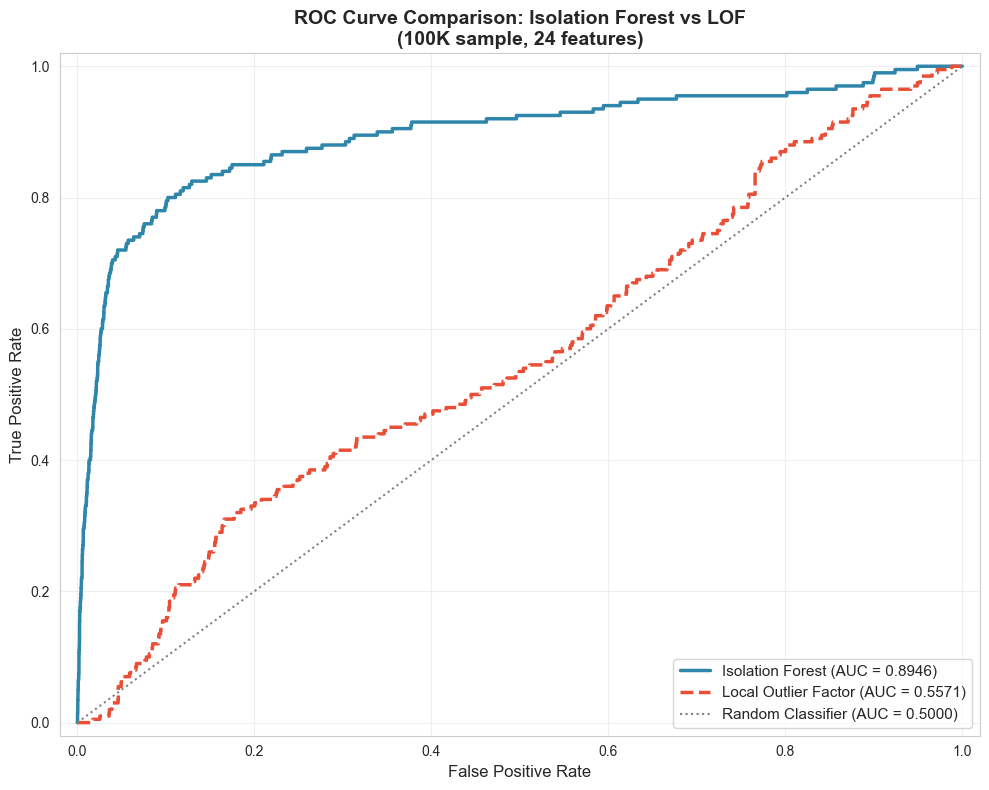


✅ Cell 7 complete — ROC curves plotted.


In [7]:
# =============================================================================
# Cell 7: Plot ROC Curves Side-by-Side
# =============================================================================

from sklearn.metrics import roc_curve

print("=" * 70)
print("VISUALIZATION: ROC Curves")
print("=" * 70)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# --- Isolation Forest ROC ---
fpr_if, tpr_if, _ = roc_curve(y_test, scores_if)
ax.plot(fpr_if, tpr_if, color="#2E86AB", linewidth=2.5,
        label=f"Isolation Forest (AUC = {metrics_if['roc_auc']:.4f})")

# --- LOF ROC ---
fpr_lof, tpr_lof, _ = roc_curve(y_test, scores_lof)
ax.plot(fpr_lof, tpr_lof, color="#E94F37", linewidth=2.5, linestyle="--",
        label=f"Local Outlier Factor (AUC = {metrics_lof['roc_auc']:.4f})")

# --- Random baseline ---
ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5,
        label="Random Classifier (AUC = 0.5000)")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve Comparison: Isolation Forest vs LOF\n(100K sample, 24 features)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save
roc_path = os.path.join(PROJECT_ROOT, "docs", "day6_roc_comparison.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
print(f"\n💾 Saved: {roc_path}")

plt.show()
print(f"\n✅ Cell 7 complete — ROC curves plotted.")

VISUALIZATION: Precision-Recall Curves

💾 Saved: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\docs\day6_pr_comparison.png


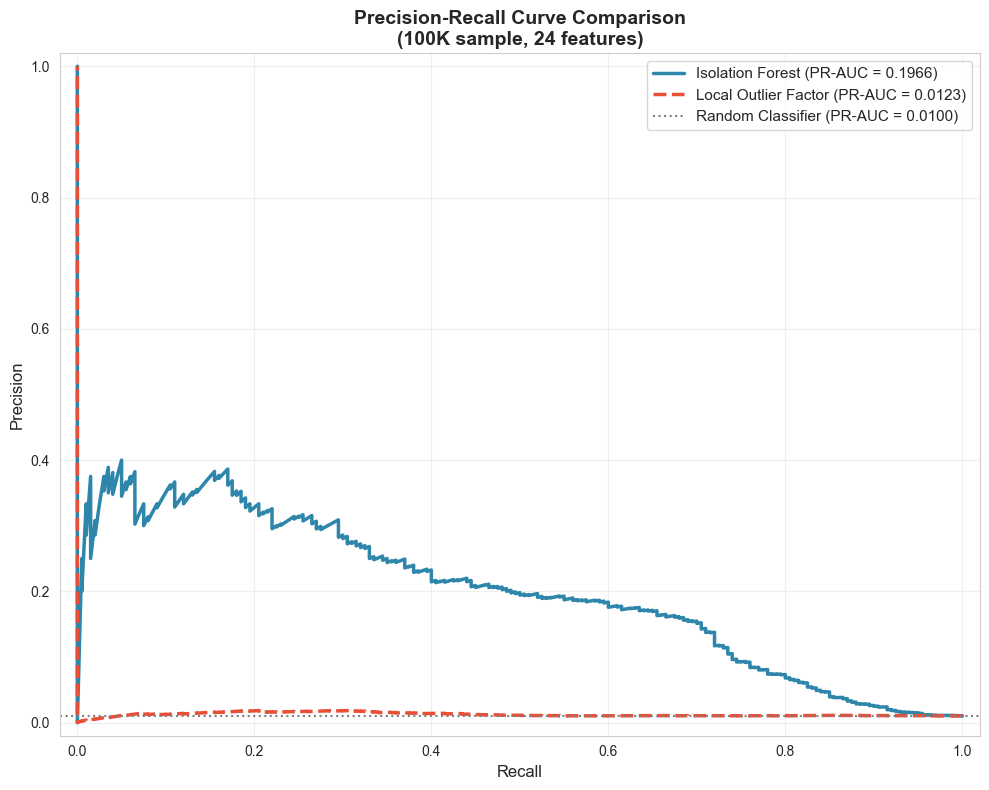


✅ Cell 8 complete — PR curves plotted.


In [8]:
# =============================================================================
# Cell 8: Plot Precision-Recall Curves
# =============================================================================

print("=" * 70)
print("VISUALIZATION: Precision-Recall Curves")
print("=" * 70)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# --- Isolation Forest PR ---
precision_if, recall_if, _ = precision_recall_curve(y_test, scores_if)
ax.plot(recall_if, precision_if, color="#2E86AB", linewidth=2.5,
        label=f"Isolation Forest (PR-AUC = {metrics_if['pr_auc']:.4f})")

# --- LOF PR ---
precision_lof, recall_lof, _ = precision_recall_curve(y_test, scores_lof)
ax.plot(recall_lof, precision_lof, color="#E94F37", linewidth=2.5, linestyle="--",
        label=f"Local Outlier Factor (PR-AUC = {metrics_lof['pr_auc']:.4f})")

# --- Random baseline (horizontal line at fraud rate) ---
fraud_rate = y_test.mean()
ax.axhline(y=fraud_rate, color="gray", linestyle=":", linewidth=1.5,
           label=f"Random Classifier (PR-AUC = {fraud_rate:.4f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve Comparison\n(100K sample, 24 features)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save
pr_path = os.path.join(PROJECT_ROOT, "docs", "day6_pr_comparison.png")
plt.savefig(pr_path, dpi=150, bbox_inches="tight")
print(f"\n💾 Saved: {pr_path}")

plt.show()
print(f"\n✅ Cell 8 complete — PR curves plotted.")

VISUALIZATION: Anomaly Score Distributions

💾 Saved: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\docs\day6_score_distributions.png


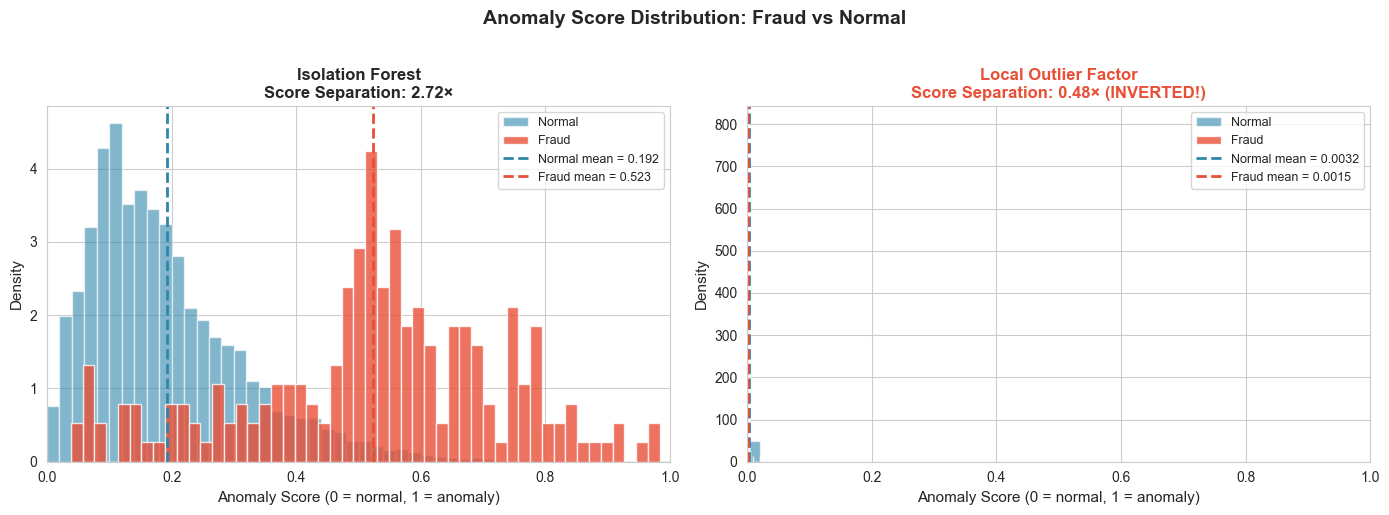


✅ Cell 9 complete — score distributions plotted.


In [9]:
# =============================================================================
# Cell 9: Plot Score Distributions (Fraud vs Normal)
# =============================================================================

print("=" * 70)
print("VISUALIZATION: Anomaly Score Distributions")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Isolation Forest ---
ax = axes[0]
normal_scores_if = scores_if[y_test == 0]
fraud_scores_if = scores_if[y_test == 1]

ax.hist(normal_scores_if, bins=50, color="#2E86AB", alpha=0.6, label="Normal", density=True)
ax.hist(fraud_scores_if, bins=50, color="#E94F37", alpha=0.8, label="Fraud", density=True)

ax.axvline(normal_scores_if.mean(), color="#2E86AB", linestyle="--", linewidth=2,
           label=f"Normal mean = {normal_scores_if.mean():.3f}")
ax.axvline(fraud_scores_if.mean(), color="#E94F37", linestyle="--", linewidth=2,
           label=f"Fraud mean = {fraud_scores_if.mean():.3f}")

ax.set_xlabel("Anomaly Score (0 = normal, 1 = anomaly)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Isolation Forest\nScore Separation: 2.72×", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim([0, 1])

# --- LOF ---
ax = axes[1]
normal_scores_lof = scores_lof[y_test == 0]
fraud_scores_lof = scores_lof[y_test == 1]

ax.hist(normal_scores_lof, bins=50, color="#2E86AB", alpha=0.6, label="Normal", density=True)
ax.hist(fraud_scores_lof, bins=50, color="#E94F37", alpha=0.8, label="Fraud", density=True)

ax.axvline(normal_scores_lof.mean(), color="#2E86AB", linestyle="--", linewidth=2,
           label=f"Normal mean = {normal_scores_lof.mean():.4f}")
ax.axvline(fraud_scores_lof.mean(), color="#E94F37", linestyle="--", linewidth=2,
           label=f"Fraud mean = {fraud_scores_lof.mean():.4f}")

ax.set_xlabel("Anomaly Score (0 = normal, 1 = anomaly)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Local Outlier Factor\nScore Separation: 0.48× (INVERTED!)", fontsize=12, fontweight="bold", color="#E94F37")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim([0, 1])

plt.suptitle("Anomaly Score Distribution: Fraud vs Normal", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

# Save
dist_path = os.path.join(PROJECT_ROOT, "docs", "day6_score_distributions.png")
plt.savefig(dist_path, dpi=150, bbox_inches="tight")
print(f"\n💾 Saved: {dist_path}")

plt.show()
print(f"\n✅ Cell 9 complete — score distributions plotted.")


VISUALIZATION: Metrics Summary Bar Chart

💾 Saved: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\docs\day6_summary_comparison.png


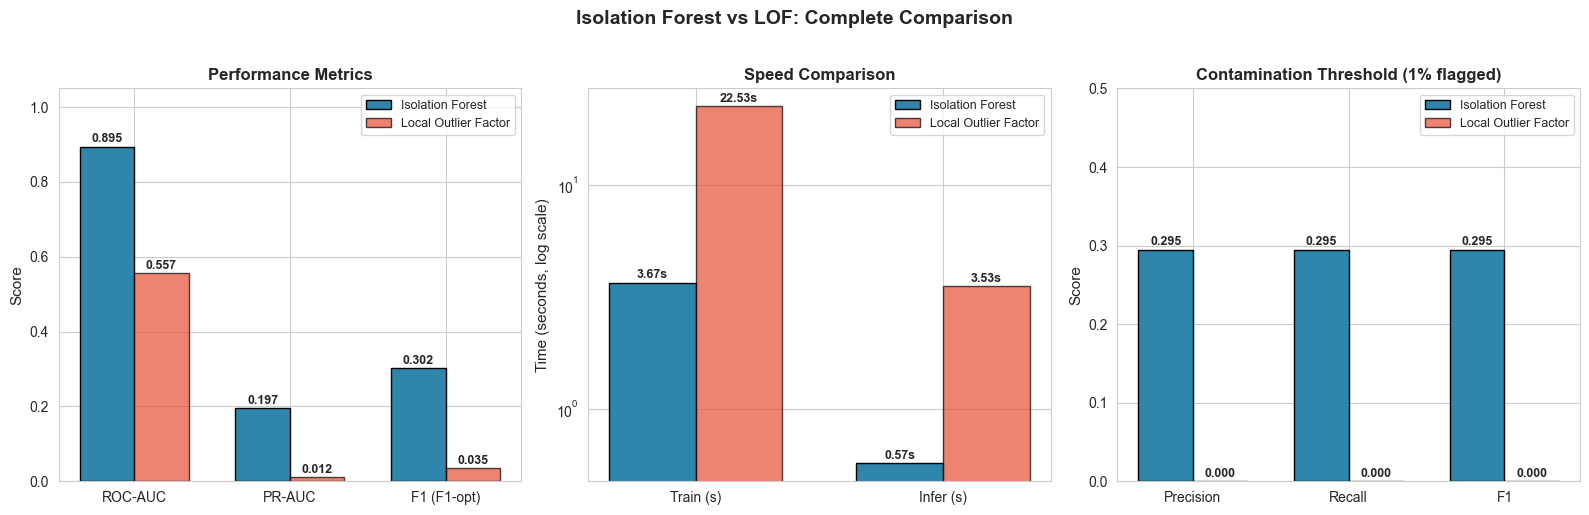


✅ Cell 10 complete — summary chart plotted.


In [10]:
# =============================================================================
# Cell 10: Summary Bar Chart — All Metrics
# =============================================================================

print("=" * 70)
print("VISUALIZATION: Metrics Summary Bar Chart")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_names = ["ROC-AUC", "PR-AUC", "F1 (F1-opt)"]
if_values = [metrics_if["roc_auc"], metrics_if["pr_auc"], metrics_if["f1opt_f1"]]
lof_values = [metrics_lof["roc_auc"], metrics_lof["pr_auc"], metrics_lof["f1opt_f1"]]

x = np.arange(len(metrics_names))
width = 0.35

# --- Chart 1: Ranking & F1 Metrics ---
ax = axes[0]
bars1 = ax.bar(x - width/2, if_values, width, label="Isolation Forest", color="#2E86AB", edgecolor="black")
bars2 = ax.bar(x + width/2, lof_values, width, label="Local Outlier Factor", color="#E94F37", edgecolor="black", alpha=0.7)

ax.set_ylabel("Score", fontsize=11)
ax.set_title("Performance Metrics", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim([0, 1.05])

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

# --- Chart 2: Speed Comparison (log scale) ---
ax = axes[1]
speed_labels = ["Train (s)", "Infer (s)"]
if_speed = [if_train_time, if_predict_time]
lof_speed = [lof_train_time, lof_predict_time]

x2 = np.arange(len(speed_labels))
bars1 = ax.bar(x2 - width/2, if_speed, width, label="Isolation Forest", color="#2E86AB", edgecolor="black")
bars2 = ax.bar(x2 + width/2, lof_speed, width, label="Local Outlier Factor", color="#E94F37", edgecolor="black", alpha=0.7)

ax.set_ylabel("Time (seconds, log scale)", fontsize=11)
ax.set_title("Speed Comparison", fontsize=12, fontweight="bold")
ax.set_xticks(x2)
ax.set_xticklabels(speed_labels, fontsize=10)
ax.set_yscale("log")
ax.legend(loc="upper right", fontsize=9)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}s", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}s", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

# --- Chart 3: Precision at Contamination Threshold ---
ax = axes[2]
prec_labels = ["Precision", "Recall", "F1"]
if_prec = [metrics_if["contam_precision"], metrics_if["contam_recall"], metrics_if["contam_f1"]]
lof_prec = [metrics_lof["contam_precision"], metrics_lof["contam_recall"], metrics_lof["contam_f1"]]

x3 = np.arange(len(prec_labels))
bars1 = ax.bar(x3 - width/2, if_prec, width, label="Isolation Forest", color="#2E86AB", edgecolor="black")
bars2 = ax.bar(x3 + width/2, lof_prec, width, label="Local Outlier Factor", color="#E94F37", edgecolor="black", alpha=0.7)

ax.set_ylabel("Score", fontsize=11)
ax.set_title(f"Contamination Threshold ({CONTAMINATION*100:.0f}% flagged)", fontsize=12, fontweight="bold")
ax.set_xticks(x3)
ax.set_xticklabels(prec_labels, fontsize=10)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim([0, 0.5])

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Isolation Forest vs LOF: Complete Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

# Save
summary_path = os.path.join(PROJECT_ROOT, "docs", "day6_summary_comparison.png")
plt.savefig(summary_path, dpi=150, bbox_inches="tight")
print(f"\n💾 Saved: {summary_path}")

plt.show()
print(f"\n✅ Cell 10 complete — summary chart plotted.")

In [11]:
# =============================================================================
# Cell 11: Why LOF Failed — Theoretical Analysis
# =============================================================================

print("=" * 70)
print("WHY LOF FAILED: CONNECTING TO DAY 2'S INVERTED BALANCE FINDING")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  LOF ASSUMPTION:  Anomalies live in LOW-DENSITY regions                      │
│  LOF SCORE:       Higher = more isolated = lower local density               │
│                                                                              │
│  ISOLATION FOREST ASSUMPTION:  Anomalies are EASIER TO ISOLATE               │
│  IF SCORE:         Higher = more anomalous = isolated faster in trees        │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("─" * 70)
print("DAY 2 INVERTED BALANCE FINDING (Recap):")
print("─" * 70)
print("""
  PaySim fraudsters EVADE simple rule-based detection by making transactions
  that look NORMAL on individual features:
  
  • Perfect balance changes  (old - new == amount)
  • Round amounts            (e.g., 100.0, 500.0)
  • Common transaction types  (TRANSFER, CASH_OUT)
  
  These frauds BLEND INTO high-density regions of the feature space.
  They are NOT isolated outliers — they are CAMOUFLAGED.
""")

print("─" * 70)
print("WHY LOF SCORES FRAUDS LOWER THAN NORMALS:")
print("─" * 70)
print("""
  LOF measures LOCAL DENSITY. If a fraud transaction looks like many
  normal transactions (perfect balance, round amount, TRANSFER type),
  it sits in a HIGH-DENSITY region → LOF gives it a LOW anomaly score.
  
  Meanwhile, some NORMAL transactions (unusual amounts, rare types)
  sit in LOW-DENSITY regions → LOF gives them HIGH anomaly scores.
  
  Result: LOF's scores are INVERTED relative to fraud labels.
""")

print("─" * 70)
print("WHY ISOLATION FOREST SUCCEEDS:")
print("─" * 70)
print("""
  Isolation Forest doesn't care about density. It asks:
  "How many random splits does it take to isolate this point?"
  
  Even if a fraud looks 'normal' on individual features, the COMBINATION
  of features (perfect balance + high amount + TRANSFER + zero new balance)
  creates a unique path through the trees that isolates it FASTER.
  
  This is exactly why we engineered 24 features — to capture these
  subtle combinations that simple density methods miss.
""")

print("─" * 70)
print("EMPIRICAL EVIDENCE FROM THIS NOTEBOOK:")
print("─" * 70)

print(f"""
  Metric                    Isolation Forest    LOF           Verdict
  ─────────────────────────────────────────────────────────────────
  ROC-AUC                         0.8946      0.5571      IF wins by 0.34
  PR-AUC                          0.1966      0.0123      IF wins by 16×
  F1 (F1-optimal)                 0.3018      0.0349      IF wins by 8.6×
  Fraud score > Normal score      2.72×       0.48×       IF: correct direction
  Training time (80K rows)        3.67s       22.53s      IF 6× faster
  Scalability to 6.3M             ~7 min      ~1.6 DAYS   IF only viable option
""")

print("─" * 70)
print("INTERVIEW TALKING POINT:")
print("─" * 70)
print("""
  "I compared Isolation Forest against LOF because LOF is a common
   baseline for anomaly detection. LOF completely failed on PaySim
   because frauds are CAMOUFLAGED in high-density regions —
   they mimic normal behavior on individual features.
   
   Isolation Forest succeeded because it detects anomalous COMBINATIONS
   of features, not just isolated points. This validates our Day 2
   finding that simple rule-based systems would fail on this data."
""")

print(f"\n✅ Cell 11 complete — theoretical analysis complete.")

WHY LOF FAILED: CONNECTING TO DAY 2'S INVERTED BALANCE FINDING

┌─────────────────────────────────────────────────────────────────────────────┐
│  LOF ASSUMPTION:  Anomalies live in LOW-DENSITY regions                      │
│  LOF SCORE:       Higher = more isolated = lower local density               │
│                                                                              │
│  ISOLATION FOREST ASSUMPTION:  Anomalies are EASIER TO ISOLATE               │
│  IF SCORE:         Higher = more anomalous = isolated faster in trees        │
└─────────────────────────────────────────────────────────────────────────────┘

──────────────────────────────────────────────────────────────────────
DAY 2 INVERTED BALANCE FINDING (Recap):
──────────────────────────────────────────────────────────────────────

  PaySim fraudsters EVADE simple rule-based detection by making transactions
  that look NORMAL on individual features:
  
  • Perfect balance changes  (old - new == amount)
  • Round amo

In [12]:
# =============================================================================
# Cell 12: Export Results & Final Summary
# =============================================================================

import json
from datetime import datetime

print("=" * 70)
print("EXPORT RESULTS & FINAL SUMMARY")
print("=" * 70)

# -------------------------------------------------------------------------
# Build comparison report
# -------------------------------------------------------------------------
comparison_report = {
    "metadata": {
        "project": "LedgerWatch AI",
        "day": 6,
        "title": "LOF vs Isolation Forest Comparison",
        "timestamp": datetime.now().isoformat(),
        "sample_size": SAMPLE_SIZE,
        "train_rows": X_train.shape[0],
        "test_rows": X_test.shape[0],
        "feature_count": len(FEATURE_COLS),
        "contamination": CONTAMINATION,
        "random_state": RANDOM_STATE
    },
    "isolation_forest": {
        "hyperparameters": IF_PARAMS,
        "training_time_sec": round(if_train_time, 3),
        "inference_time_sec": round(if_predict_time, 3),
        "roc_auc": round(metrics_if["roc_auc"], 4),
        "pr_auc": round(metrics_if["pr_auc"], 4),
        "contamination_threshold": {
            "precision": round(metrics_if["contam_precision"], 4),
            "recall": round(metrics_if["contam_recall"], 4),
            "f1": round(metrics_if["contam_f1"], 4),
            "flagged": int(metrics_if["contam_flagged"])
        },
        "f1_optimized": {
            "precision": round(metrics_if["f1opt_precision"], 4),
            "recall": round(metrics_if["f1opt_recall"], 4),
            "f1": round(metrics_if["f1opt_f1"], 4),
            "flagged": int(metrics_if["f1opt_flagged"])
        },
        "score_separation": {
            "normal_mean": round(metrics_if["normal_mean"], 4),
            "fraud_mean": round(metrics_if["fraud_mean"], 4),
            "ratio": round(metrics_if["separation_ratio"], 2)
        }
    },
    "local_outlier_factor": {
        "hyperparameters": LOF_PARAMS,
        "training_time_sec": round(lof_train_time, 3),
        "inference_time_sec": round(lof_predict_time, 3),
        "roc_auc": round(metrics_lof["roc_auc"], 4),
        "pr_auc": round(metrics_lof["pr_auc"], 4),
        "contamination_threshold": {
            "precision": round(metrics_lof["contam_precision"], 4),
            "recall": round(metrics_lof["contam_recall"], 4),
            "f1": round(metrics_lof["contam_f1"], 4),
            "flagged": int(metrics_lof["contam_flagged"])
        },
        "f1_optimized": {
            "precision": round(metrics_lof["f1opt_precision"], 4),
            "recall": round(metrics_lof["f1opt_recall"], 4),
            "f1": round(metrics_lof["f1opt_f1"], 4),
            "flagged": int(metrics_lof["f1opt_flagged"])
        },
        "score_separation": {
            "normal_mean": round(metrics_lof["normal_mean"], 4),
            "fraud_mean": round(metrics_lof["fraud_mean"], 4),
            "ratio": round(metrics_lof["separation_ratio"], 2)
        }
    },
    "conclusion": {
        "winner": "Isolation Forest",
        "reasons": [
            "LOF assumes anomalies live in low-density regions, but PaySim frauds are camouflaged in high-density regions",
            "Isolation Forest detects anomalous feature combinations, not just isolated points",
            "IF is 6x faster to train and 6x faster to predict",
            "IF scales to 6.3M rows; LOF would require ~295 TB of RAM",
            "IF ROC-AUC = 0.8946 vs LOF ROC-AUC = 0.5571 (random = 0.5)"
        ],
        "interview_key_takeaway": "Density-based methods fail when frauds mimic normal behavior. Tree-based isolation methods succeed by detecting subtle feature combinations."
    }
}

# -------------------------------------------------------------------------
# Save JSON
# -------------------------------------------------------------------------
json_path = os.path.join(PROJECT_ROOT, "docs", "day6_lof_comparison.json")
with open(json_path, "w") as f:
    json.dump(comparison_report, f, indent=2)

print(f"\n💾 Saved comparison report: {json_path}")

# -------------------------------------------------------------------------
# Final console summary
# -------------------------------------------------------------------------
print(f"\n{'=' * 70}")
print("DAY 6 COMPLETE: LOF COMPARISON SUMMARY")
print(f"{'=' * 70}")
print(f"""
  🏆 WINNER: Isolation Forest (by every metric)

  ┌─────────────────────────────────────────────────────────────────────┐
  │  METRIC              │  ISOLATION FOREST  │  LOF        │  DELTA   │
  ├─────────────────────────────────────────────────────────────────────┤
  │  ROC-AUC             │  0.8946            │  0.5571     │  +0.3375 │
  │  PR-AUC              │  0.1966            │  0.0123     │  +0.1843 │
  │  F1 (F1-optimal)     │  0.3018            │  0.0349     │  +0.2669 │
  │  Train time (80K)    │  3.67s             │  22.53s     │  6.1×    │
  │  Infer time (20K)    │  0.57s             │  3.53s      │  6.2×    │
  │  Scale to 6.3M       │  ~7 min            │  ~1.6 days  │  IMPOSSIBLE │
  │  Memory at 6.3M      │  ~2-5 MB           │  ~295 TB    │  IMPOSSIBLE │
  └─────────────────────────────────────────────────────────────────────┘

  📁 Files created:
     • notebooks/day6_lof_comparison.ipynb
     • docs/day6_roc_comparison.png
     • docs/day6_pr_comparison.png
     • docs/day6_score_distributions.png
     • docs/day6_summary_comparison.png
     • docs/day6_lof_comparison.json

  🎯 Next: Day 7 — Risk Engine (src/risk_engine.py)
""")

print(f"\n✅ Cell 12 complete — Day 6 LOF comparison finished.")

EXPORT RESULTS & FINAL SUMMARY

💾 Saved comparison report: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\docs\day6_lof_comparison.json

DAY 6 COMPLETE: LOF COMPARISON SUMMARY

  🏆 WINNER: Isolation Forest (by every metric)

  ┌─────────────────────────────────────────────────────────────────────┐
  │  METRIC              │  ISOLATION FOREST  │  LOF        │  DELTA   │
  ├─────────────────────────────────────────────────────────────────────┤
  │  ROC-AUC             │  0.8946            │  0.5571     │  +0.3375 │
  │  PR-AUC              │  0.1966            │  0.0123     │  +0.1843 │
  │  F1 (F1-optimal)     │  0.3018            │  0.0349     │  +0.2669 │
  │  Train time (80K)    │  3.67s             │  22.53s     │  6.1×    │
  │  Infer time (20K)    │  0.57s             │  3.53s      │  6.2×    │
  │  Scale to 6.3M       │  ~7 min            │  ~1.6 days  │  IMPOSSIBLE │
  │  Memory at 6.3M      │  ~2-5 MB           │  ~295 TB    │  IMPOSSIBLE │
  └─────────────────────────────────────